In [ ]:
#Goal:
#Predict whether a credit card customer will default
#on their payment next month.
#Target:
#default.payment.next.month

In [1]:
import pandas as pd

df = pd.read_csv("../01_data/02_processed/cleaned_data.csv")

In [2]:
X=df.drop(["ID","default.payment.next.month"],axis=1)
Y=df["default.payment.next.month"]

In [3]:
print("Class counts: ")
print(Y.value_counts())
print("\nclass percentage: ")
print(Y.value_counts(normalize=True)*100)

Class counts: 
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

class percentage: 
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train_scaled,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [7]:
y_predict=model.predict(X_test_scaled)

In [8]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [9]:
from sklearn.dummy import DummyClassifier
baseline=DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_scaled,Y_train)
baseline_pred=baseline.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

print("Accuracy:", accuracy_score(Y_test, baseline_pred))
print("Recall:", recall_score(Y_test, baseline_pred))
print("F1:", f1_score(Y_test, baseline_pred))

Accuracy: 0.7788333333333334
Recall: 0.0
F1: 0.0


In [11]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score

)

test_accuracy1 = accuracy_score(Y_test, y_predict)
test_precision1 = precision_score(Y_test, y_predict)
test_recall1 = recall_score(Y_test, y_predict)
test_f11 = f1_score(Y_test, y_predict)
print("Accuracy:", test_accuracy1)
print("Recall:",test_recall1)
print("precision:",test_precision1)
print("F1: ",test_f11)
print(confusion_matrix(Y_test, y_predict))
print(classification_report(Y_test, y_predict))
print("ROC-AUC:", roc_auc_score(Y_test, y_prob))

Accuracy: 0.8076666666666666
Recall: 0.23963828183873398
precision: 0.6868250539956804
F1:  0.3553072625698324
[[4528  145]
 [1009  318]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

ROC-AUC: 0.7076355036089734


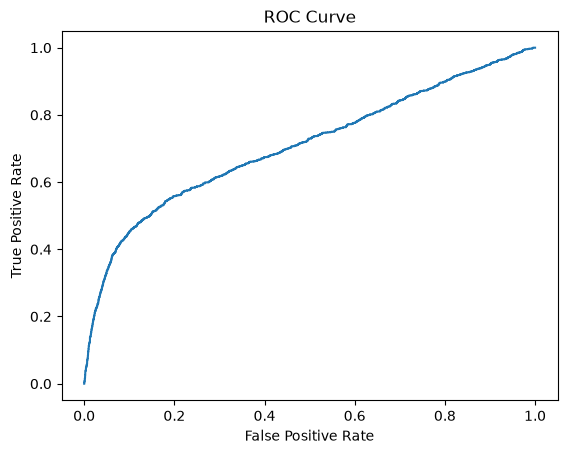

In [12]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(Y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [13]:

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression



pipeline_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced",
    max_iter=100))
])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring=["accuracy","precision","recall","f1"]
scores = cross_validate(
    pipeline_balanced,
    X_train,
    Y_train,
    cv=skf,
    scoring=scoring
)
print(scores)
print("Average Accuracy: ",scores["test_accuracy"].mean())
print("Average Precision: ",scores["test_precision"].mean())
print("Average Recall: ",scores["test_recall"].mean())
print("Average F1: ",scores["test_f1"].mean())

{'fit_time': array([0.1005826 , 0.0921731 , 0.07905531, 0.09437346, 0.10769796]), 'score_time': array([0.01817489, 0.02209854, 0.01711845, 0.02097654, 0.03055382]), 'test_accuracy': array([0.69333333, 0.69645833, 0.675     , 0.68666667, 0.70645833]), 'test_precision': array([0.38849702, 0.38681948, 0.36423119, 0.37722222, 0.39953677]), 'test_recall': array([0.67483506, 0.63559322, 0.62900188, 0.6393597 , 0.64971751]), 'test_f1': array([0.49311295, 0.48094051, 0.46132597, 0.47449336, 0.494801  ])}
Average Accuracy:  0.6915833333333332
Average Precision:  0.3832613359640629
Average Recall:  0.645701475529428
Average F1:  0.48093475712345446


In [14]:
pipeline_balanced.fit(X_train, Y_train)

y_test_pred = pipeline_balanced.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, y_test_pred))
print("Precision:", precision_score(Y_test, y_test_pred))
print("Recall:", recall_score(Y_test, y_test_pred))
print("F1:", f1_score(Y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(Y_test, y_test_pred))

Accuracy: 0.6796666666666666
Precision: 0.36724676483712626
Recall: 0.6201959306706858
F1: 0.461322869955157

Confusion Matrix:
[[3255 1418]
 [ 504  823]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000



In [15]:
import numpy as np

for metric in ["accuracy", "precision", "recall", "f1"]:
    values = scores[f"test_{metric}"]

    print(
        metric.capitalize(),
        "Mean:", values.mean(),
        "Std:", values.std()
    )

Accuracy Mean: 0.6915833333333332 Std: 0.010462067726367985
Precision Mean: 0.3832613359640629 Std: 0.0118623765106001
Recall Mean: 0.645701475529428 Std: 0.01603848947332884
F1 Mean: 0.48093475712345446 Std: 0.01238206279209391


In [16]:
comparison = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "CV Mean": [
        scores["test_accuracy"].mean(),
        scores["test_precision"].mean(),
        scores["test_recall"].mean(),
        scores["test_f1"].mean()
    ],
    "Test": [
        test_accuracy1,
        test_recall1,
        test_precision1,
        test_f11
    ]
}
print(comparison)

{'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'], 'CV Mean': [np.float64(0.6915833333333332), np.float64(0.3832613359640629), np.float64(0.645701475529428), np.float64(0.48093475712345446)], 'Test': [0.8076666666666666, 0.23963828183873398, 0.6868250539956804, 0.3553072625698324]}


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_test_pred = pipeline_balanced.predict(X_test)

test_accuracy = accuracy_score(Y_test, y_test_pred)
test_precision = precision_score(Y_test, y_test_pred)
test_recall = recall_score(Y_test, y_test_pred)
test_f1 = f1_score(Y_test, y_test_pred)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1:", test_f1)

Test Accuracy: 0.6796666666666666
Test Precision: 0.36724676483712626
Test Recall: 0.6201959306706858
Test F1: 0.461322869955157


In [18]:

print("\nCV Results")
print("Accuracy:", scores["test_accuracy"].mean())
print("Precision:", scores["test_precision"].mean())
print("Recall:", scores["test_recall"].mean())
print("F1:", scores["test_f1"].mean())

print("\nTest Results")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1:", test_f1)


CV Results
Accuracy: 0.6915833333333332
Precision: 0.3832613359640629
Recall: 0.645701475529428
F1: 0.48093475712345446

Test Results
Accuracy: 0.6796666666666666
Precision: 0.36724676483712626
Recall: 0.6201959306706858
F1: 0.461322869955157


In [19]:
y_test_proba = pipeline_balanced.predict_proba(X_test)[:, 1]

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

for threshold in thresholds:

    y_pred_threshold = (y_test_proba >= threshold).astype(int)

    precision = precision_score(Y_test, y_pred_threshold)
    recall = recall_score(Y_test, y_pred_threshold)
    f1 = f1_score(Y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.20 | Precision: 0.231 | Recall: 0.950 | F1: 0.372
Threshold: 0.30 | Precision: 0.244 | Recall: 0.888 | F1: 0.383
Threshold: 0.40 | Precision: 0.277 | Recall: 0.775 | F1: 0.408
Threshold: 0.50 | Precision: 0.367 | Recall: 0.620 | F1: 0.461
Threshold: 0.60 | Precision: 0.558 | Recall: 0.449 | F1: 0.497
Threshold: 0.70 | Precision: 0.637 | Recall: 0.347 | F1: 0.449
Threshold: 0.80 | Precision: 0.729 | Recall: 0.156 | F1: 0.257


In [20]:
chosen_threshold = 0.40
y_final_pred = (y_test_proba >= chosen_threshold).astype(int)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(Y_test, y_final_pred))
print("Precision:", precision_score(Y_test, y_final_pred))
print("Recall:", recall_score(Y_test, y_final_pred))
print("F1:", f1_score(Y_test, y_final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_final_pred))

Accuracy: 0.5016666666666667


Precision: 0.2765385649019081
Recall: 0.7754333082140166
F1: 0.40768621236133123

Confusion Matrix:
[[1981 2692]
 [ 298 1029]]


In [21]:
import joblib

joblib.dump(model, "../04_models/logistic_regression.pkl")
joblib.dump(scaler, "../04_models/scaler.pkl")

['../04_models/scaler.pkl']

In [22]:
import joblib
import os

os.makedirs("../04_models", exist_ok=True)

joblib.dump(model, "../04_models/logistic_regression.pkl")

print("Model saved successfully")

Model saved successfully


In [23]:
import joblib

loaded_model = joblib.load("../04_models/logistic_regression.pkl")

print("Model loaded successfully")
print(type(loaded_model))

Model loaded successfully
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [27]:
joblib.dump(scaler, "../04_models/scaler.pkl")

print("Scaler saved successfully")

Scaler saved successfully


In [28]:

loaded_scaler = joblib.load("../04_models/scaler.pkl")

print("Scaler loaded successfully")
print(type(loaded_scaler))

Scaler loaded successfully
<class 'sklearn.preprocessing._data.StandardScaler'>
